### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [23]:
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing', subjects=['anestis'])

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping anestis as raw folder already exists

Processing data for anestis
	Skipping 40.2.mat as it has already been processed
	Skipping 40.3.mat as it has already been processed
	Skipping 40.1.mat as it has already been processed
	Skipping 60.1.mat as it has already been processed
	Skipping 60.2.mat as it has already been processed
	Skipping 60.3.mat as it has already been processed
	Skipping 20.1.mat as it has already been processed
	Skipping 20.3.mat as it has already been processed
	Skipping 20.2.mat as it has already been processed
	Skipping 5.1.mat as it has already been processed
	Skipping 5.3.mat as it has already been processed
	Skipping 5.2.mat as it has already been processed
	Processing MVC.2.mat (MVC: 100, Trial: 2)...
	Processing MVC.1.mat (MVC: 100, Trial: 1)...
	Skipping 10.1.mat as it has already been processed
	Skipping 10.2.mat as it has already been processed
	Skipping 10.3.mat as it has already been processed
	Successfully processed data for anestis


In [24]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for anestis...


,subject,mvc_level,trial_number,neuron_data,force_data
0,anestis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.006100465392307797, -0.00610..."
1,anestis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0122009307846084..."
2,anestis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392300691, 0.0, 0.0061004653..."
3,anestis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392300691, 0.0, -0.0061004653..."
4,anestis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, -0.006100465392307797, 0...."
5,anestis,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392300691, 0.0061004653923006..."
6,anestis,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.012200930784608488, -0.00610046539230..."
7,anestis,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392300691, 0.0061004653923006..."
8,anestis,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392300691, -0.00610046539230..."
9,anestis,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.012200930784608488, -0.00610046539230..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

Purging entries with insufficient neuron data...
Purged 3 entries with insufficient neuron data. 14 entries remaining.
Computing global statistics...
	Average max activation distance: 5114.642857142857
	Max force data length: 92032
	Max number of neurons: 20
	Max number of activations: 92032
Global statistics computed.
Purging entries with inconsistent neuron data...
Purged 0 entries with inconsistent firing distances
Handling measurement correlation...
	[anestis.5.1] Both regions modified -> Skipping
	[anestis.5.2] Both regions modified -> Skipping
	[anestis.5.3] Both regions modified -> Skipping
	[anestis.10.1] Both regions modified -> Skipping
	[anestis.10.2] Both regions modified -> Skipping
	[anestis.10.3] Both regions modified -> Skipping
	[anestis.20.1] Both regions modified -> Skipping
	[anestis.20.2] Both regions modified -> Skipping
	[anestis.20.3] Both regions modified -> Skipping
	[anestis.40.1] Both regions modified -> Skipping
	[anestis.40.2] Leading turn: 11.05126953125 

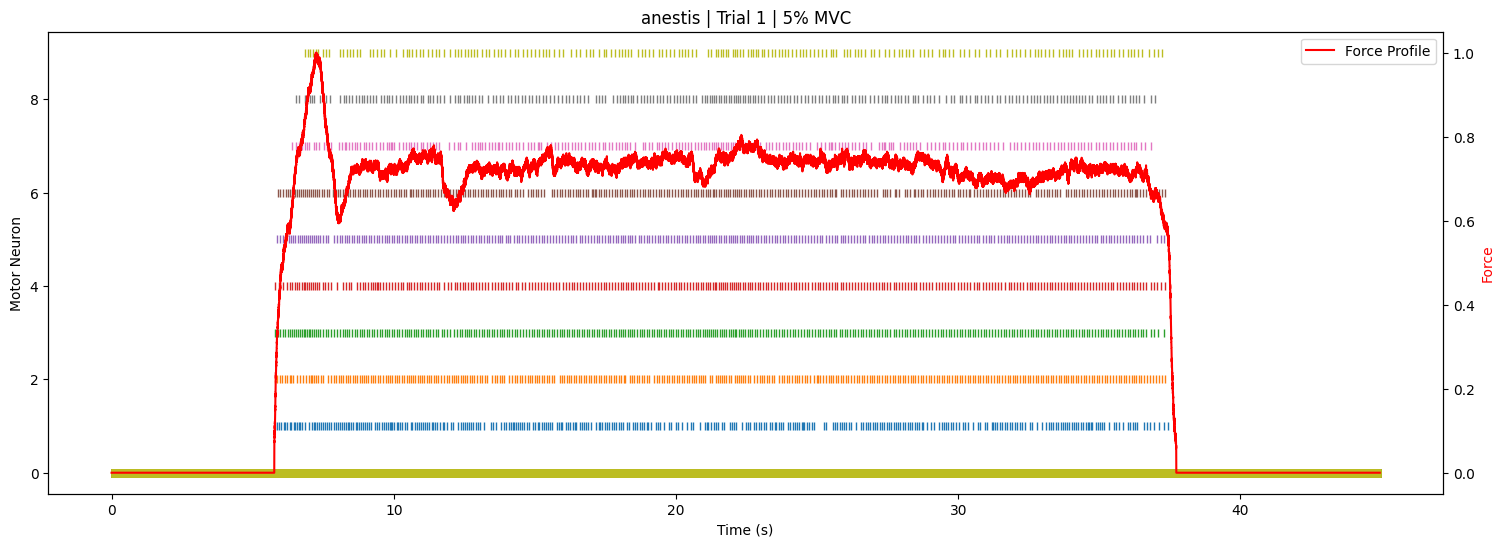

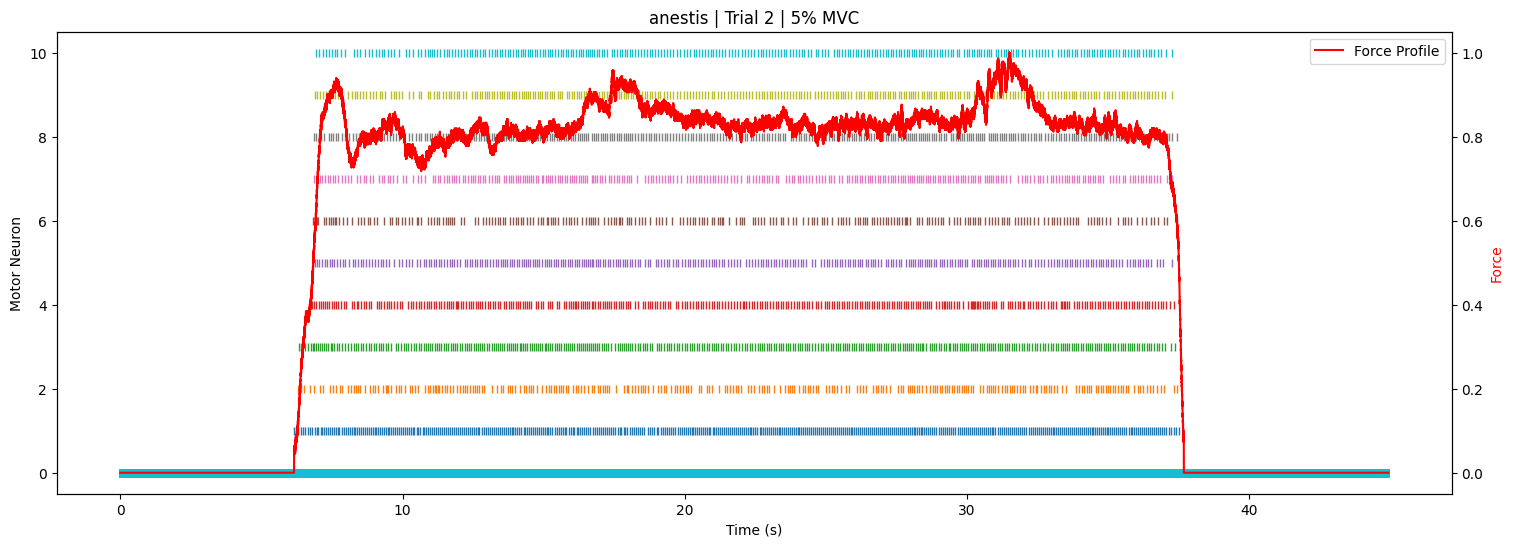

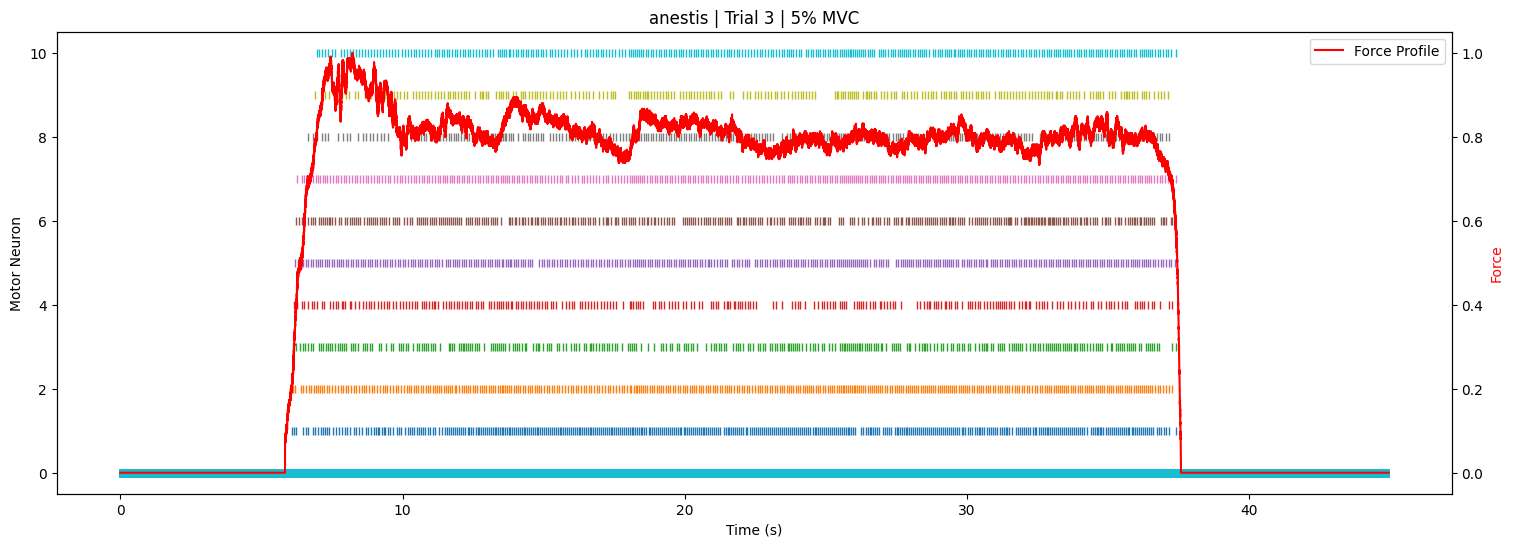

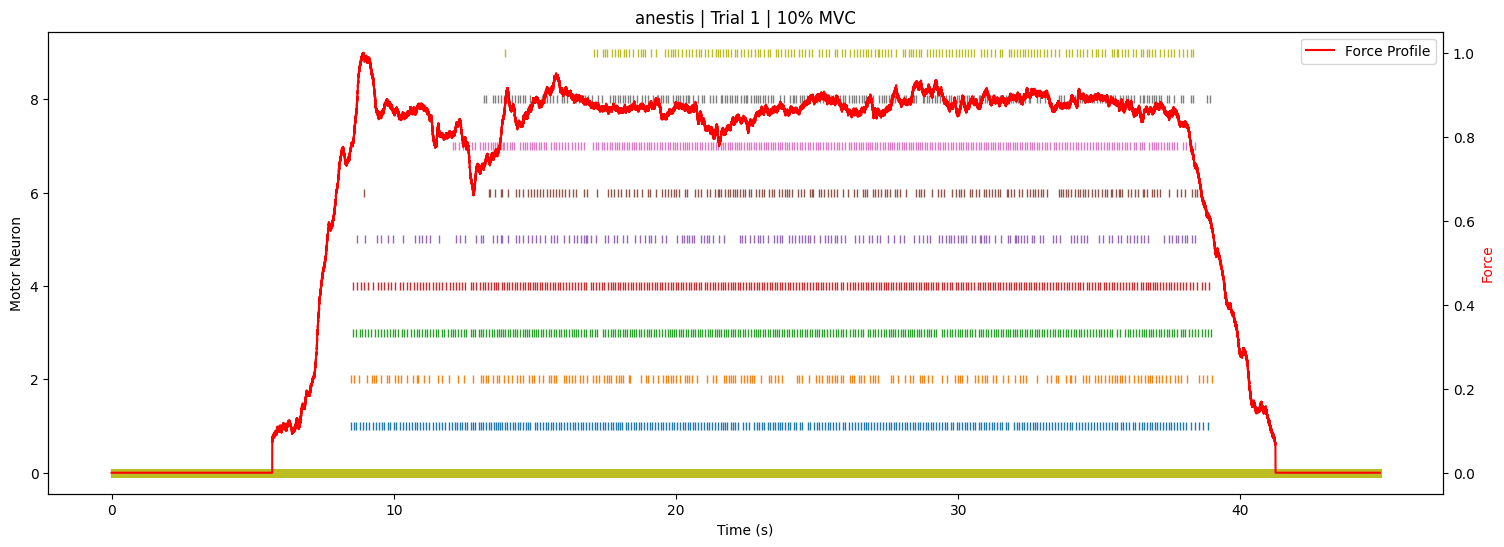

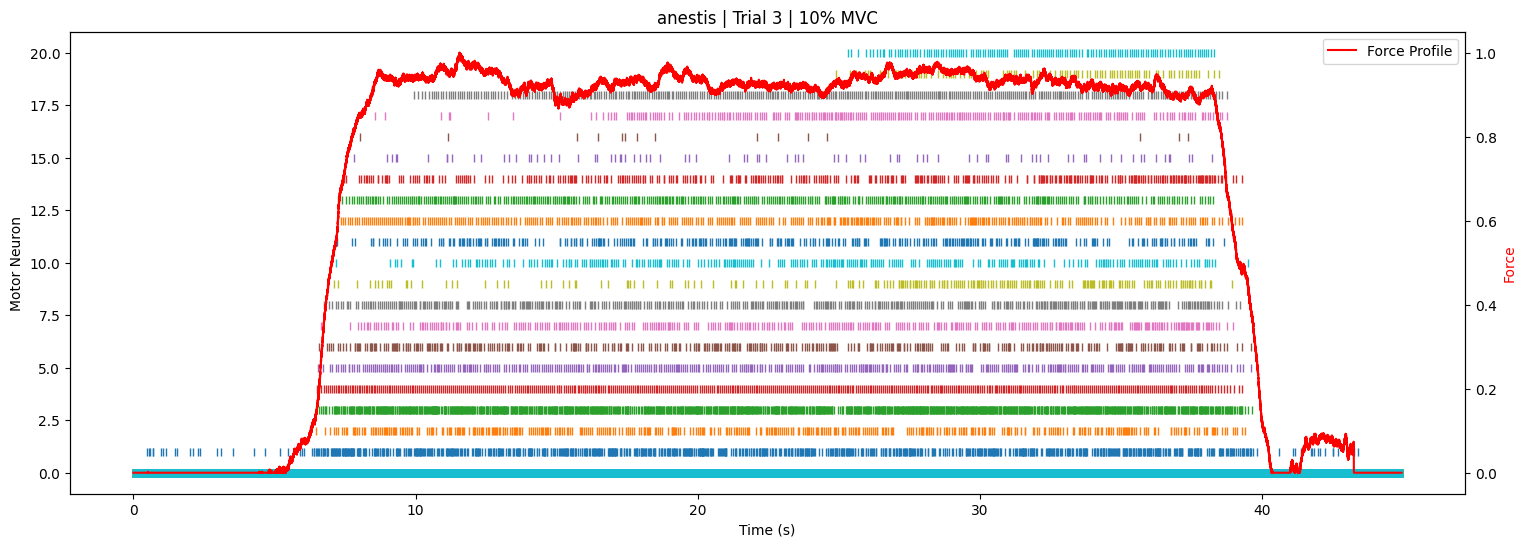

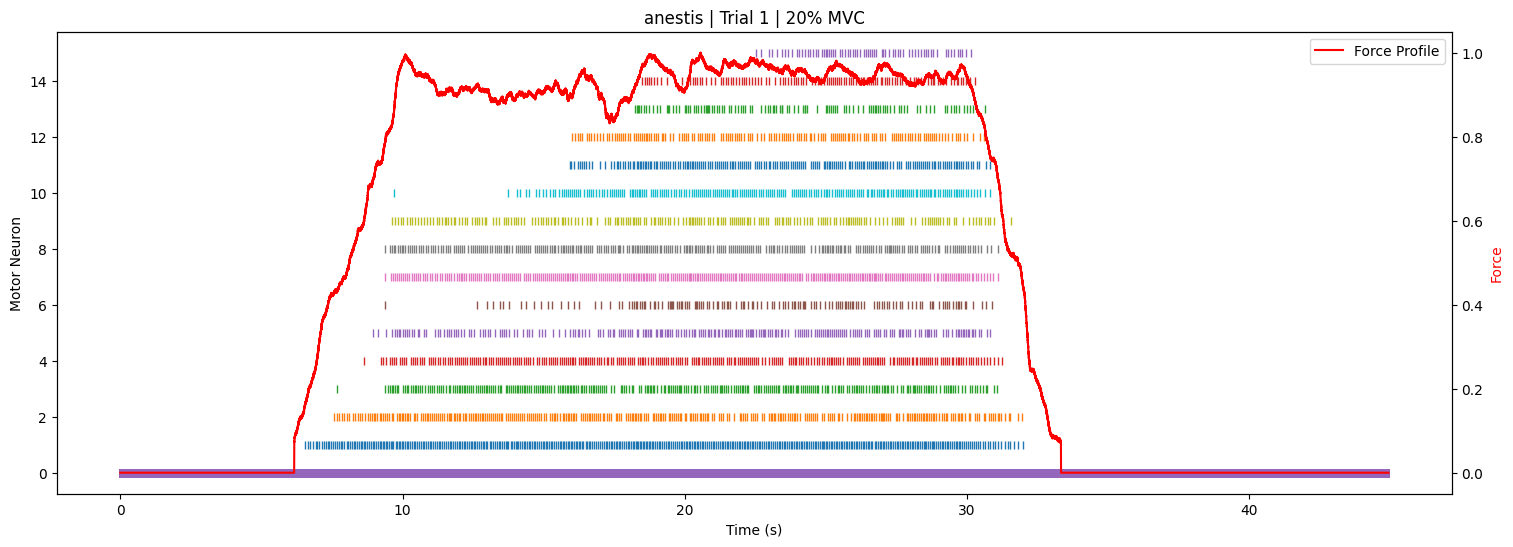

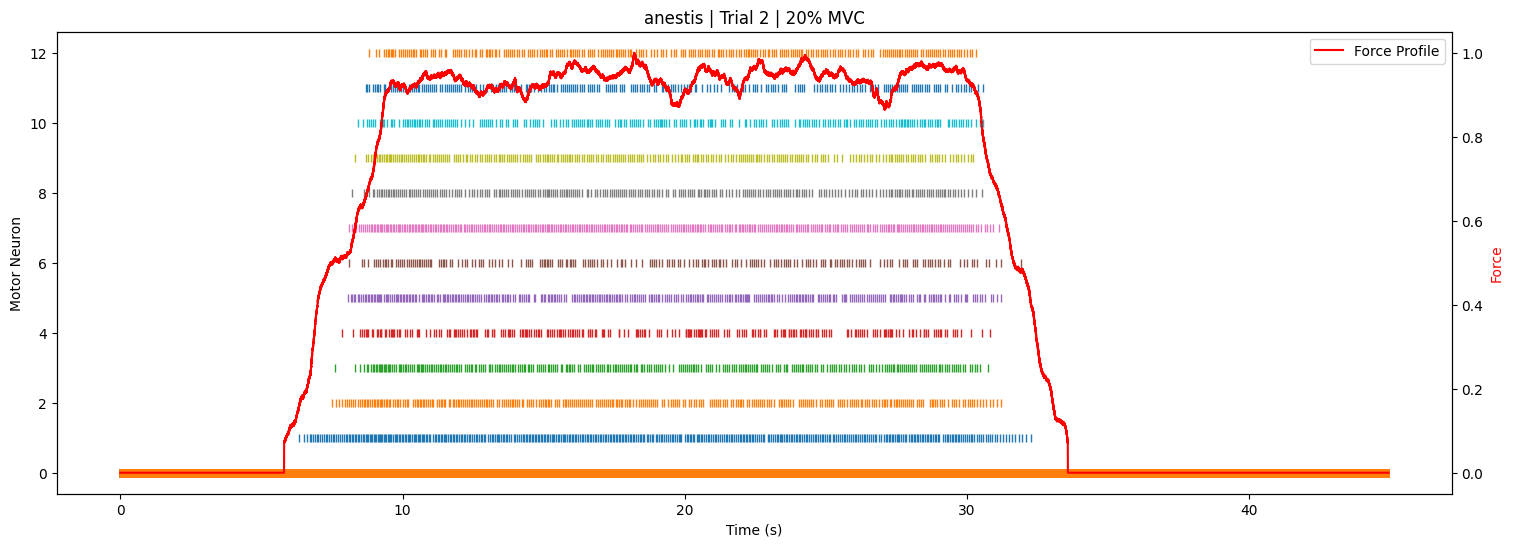

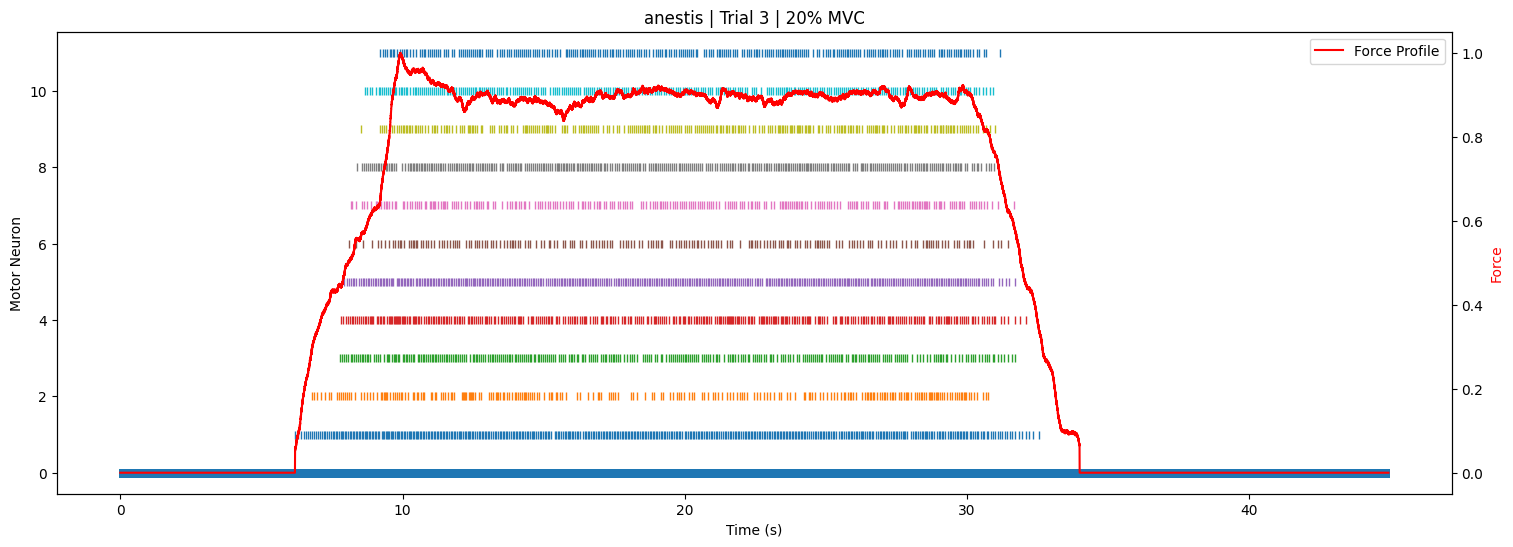

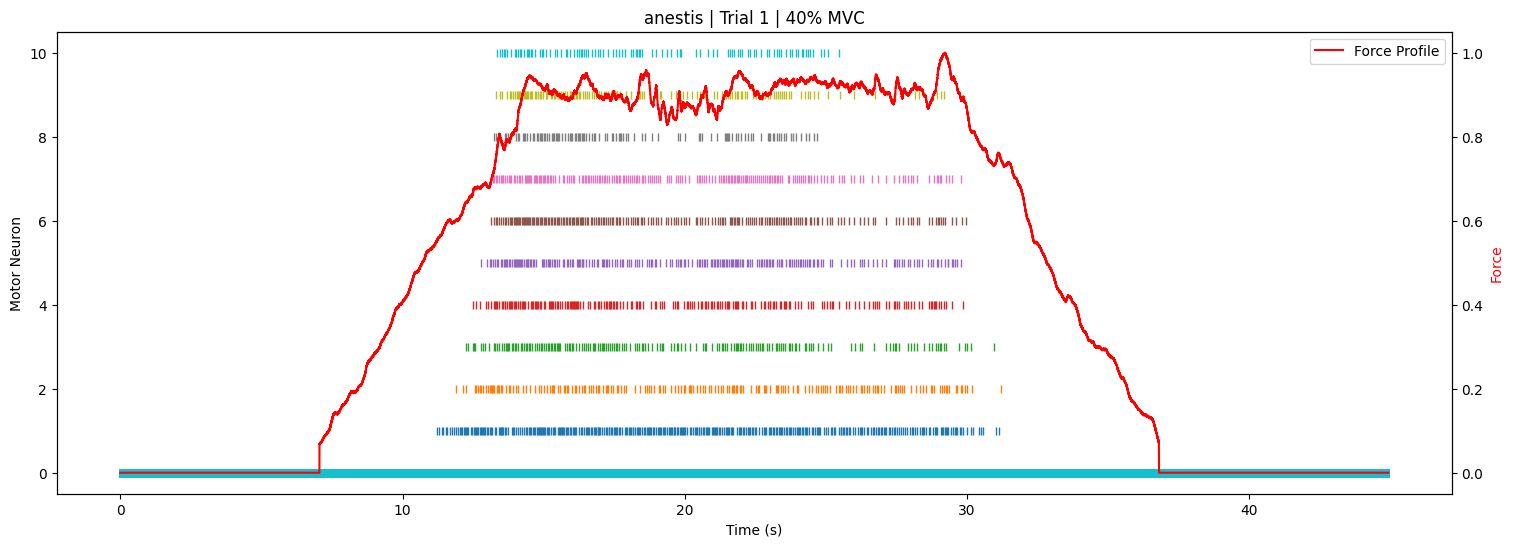

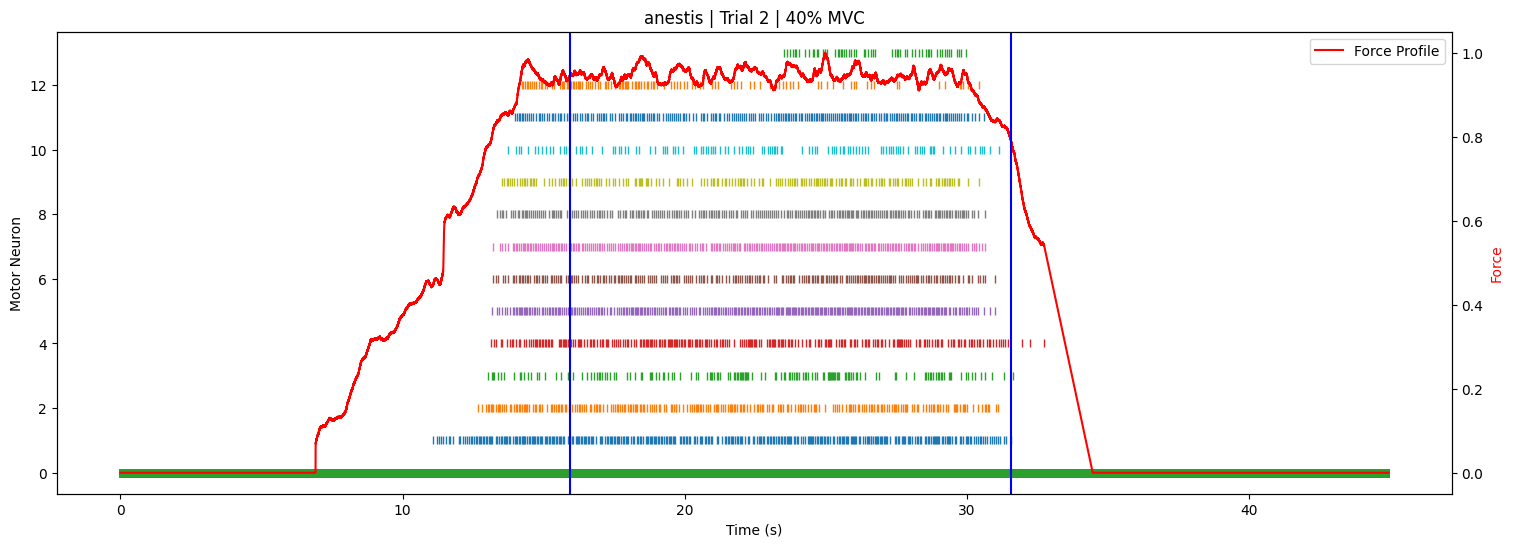

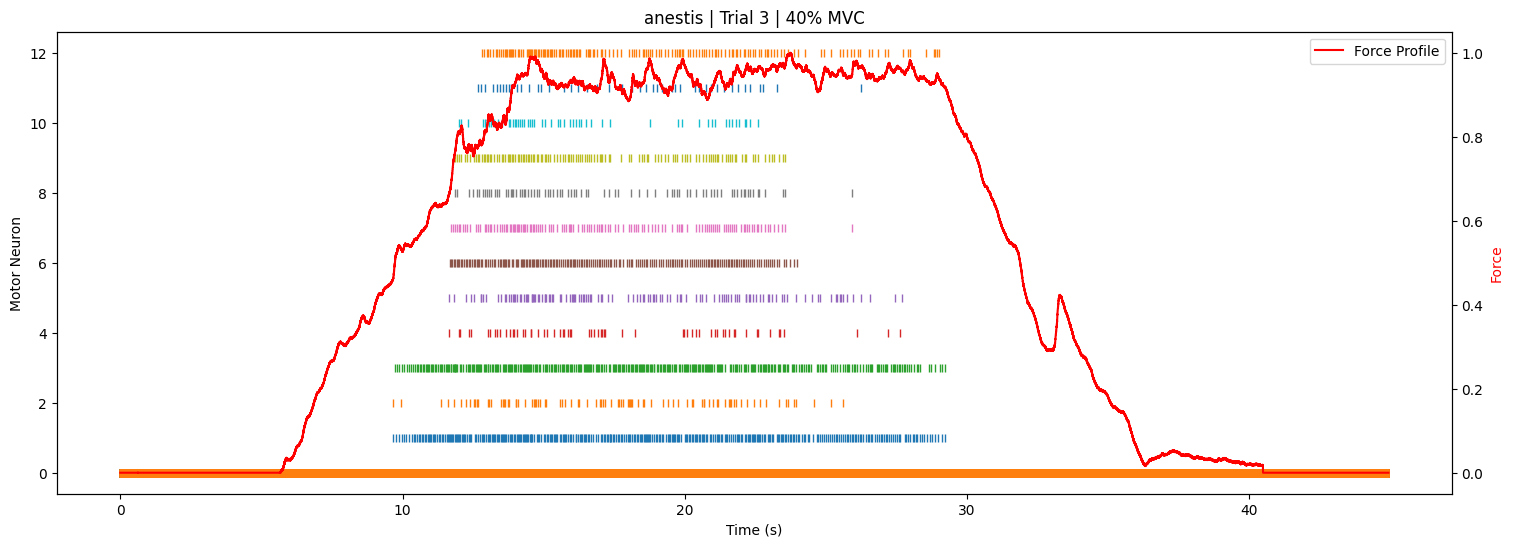

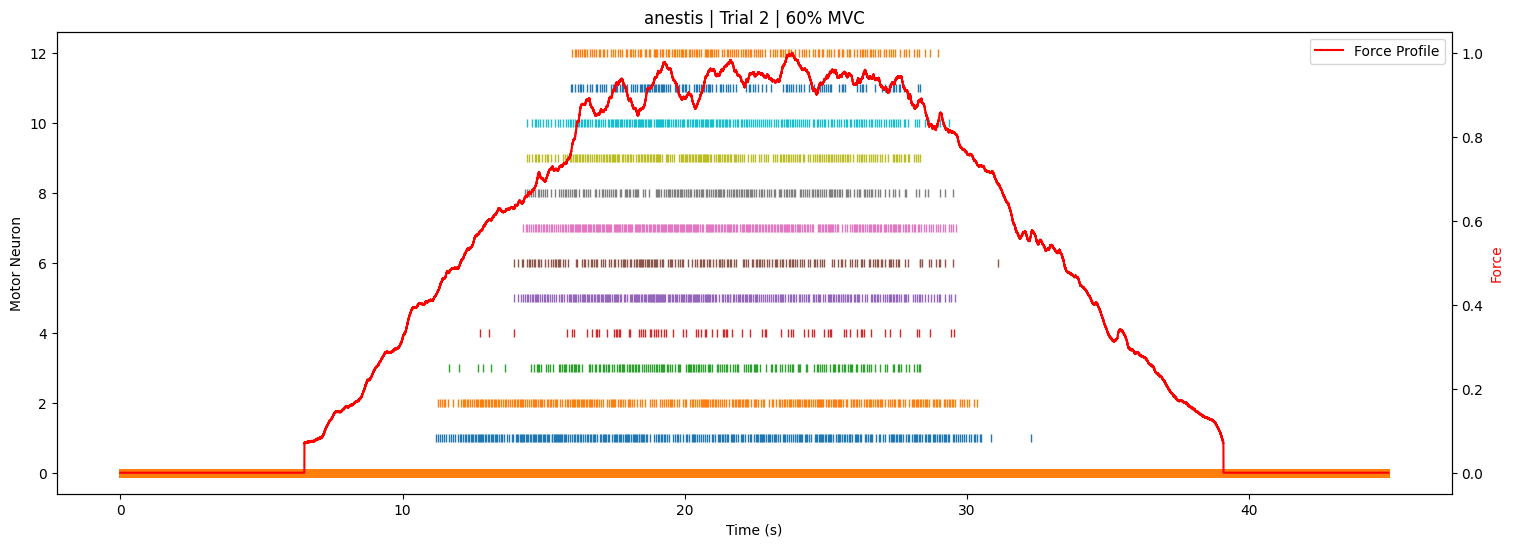

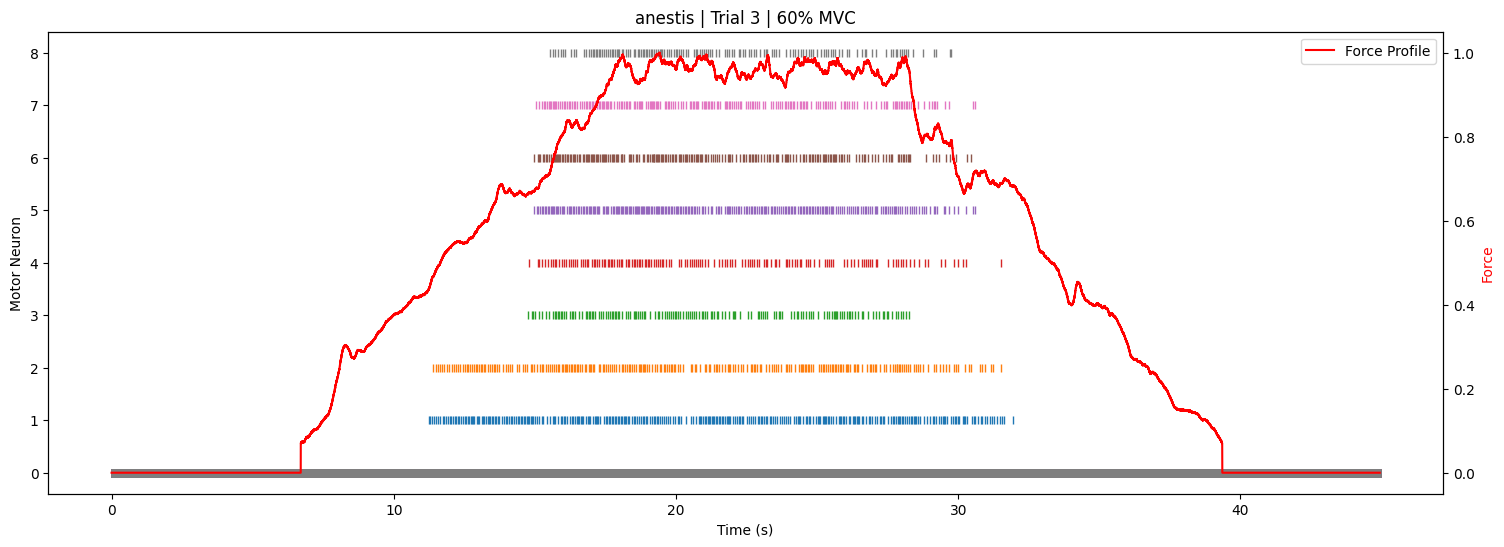

In [25]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
df = sanitizer.sanitize(export=True)

In [26]:
sanitizer.show_purged() # all entries removed during sanitization process

,subject,mvc_level,trial_number
4,anestis,10,2
12,anestis,60,1
15,anestis,100,1
16,anestis,100,2


### Direct Prediction

Directly predict force given neuron data using LSTM neural networks.

In [ ]:
import processing.processing
import prediction.constants

importlib.reload(processing.processing)

model_info = prediction.constants.models['model'] # gather model specific information for training & prediction
processor = processing.processing.Processing(df, model_info) # setup processor for model

Splits: train=11, val=1, test=2
Using default model presets 


In [ ]:
import prediction.dpm

importlib.reload(prediction.dpm)

dpm = prediction.dpm.DirectPredictionModel(processor=processor, overwrite=True)
training_history = dpm.optionally_train() # train model if necessary (no saves)

Model not found or overwrite flag is set. Creating a new model...
Training the model...
Training model | 5 Epochs | 16 Batch Size
Epoch 1/5
574/631 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.2281 - mae: 0.3577

KeyboardInterrupt: 

In [ ]:
# subject_name = 'giannatos'
# mvc_level = 5
# trial_number = 2

subject_name = 'dwrotheos'
mvc_level = 60
trial_number = 3

# subject_name = 'giannatos'
# mvc_level = 60
# trial_number = 2

trial = df[(df['subject'] == subject_name) & (df['mvc_level'] == mvc_level) & (df['trial_number'] == trial_number)].iloc[0]
predicted_force = dpm.predict(trial=trial)
predicted_force = processor.postprocess_prediction(trial, predicted_force) # postprocesses the prediction
print(f"Predicted force: {predicted_force}")

IndexError: single positional indexer is out-of-bounds

In [ ]:
from globals.visualization import visualize_trial

visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number,)
visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number, force_data=predicted_force)
visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number, predicted_force=predicted_force)

NameError: name 'subject_name' is not defined